Code to create plots for static and moving vortex ring profiles in vertical light sheet.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py


#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()
print(plt.rcParams["figure.dpi"])

# h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5')
h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')

vels = h5file['Narrow']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90)
u, v = u/0.1, v/0.1
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
vort, vortGauss = oj.calculate_vorticity(u, v)




C:/Coding/Code
C:/Coding
Thesis plot settings applied
400.0


Static vortex ring profiles

find the row at which the exit plane exists - start with row 37
maybe also have them at 3D0 so that they match the HLS experiment
increment time every second for 5 seconds

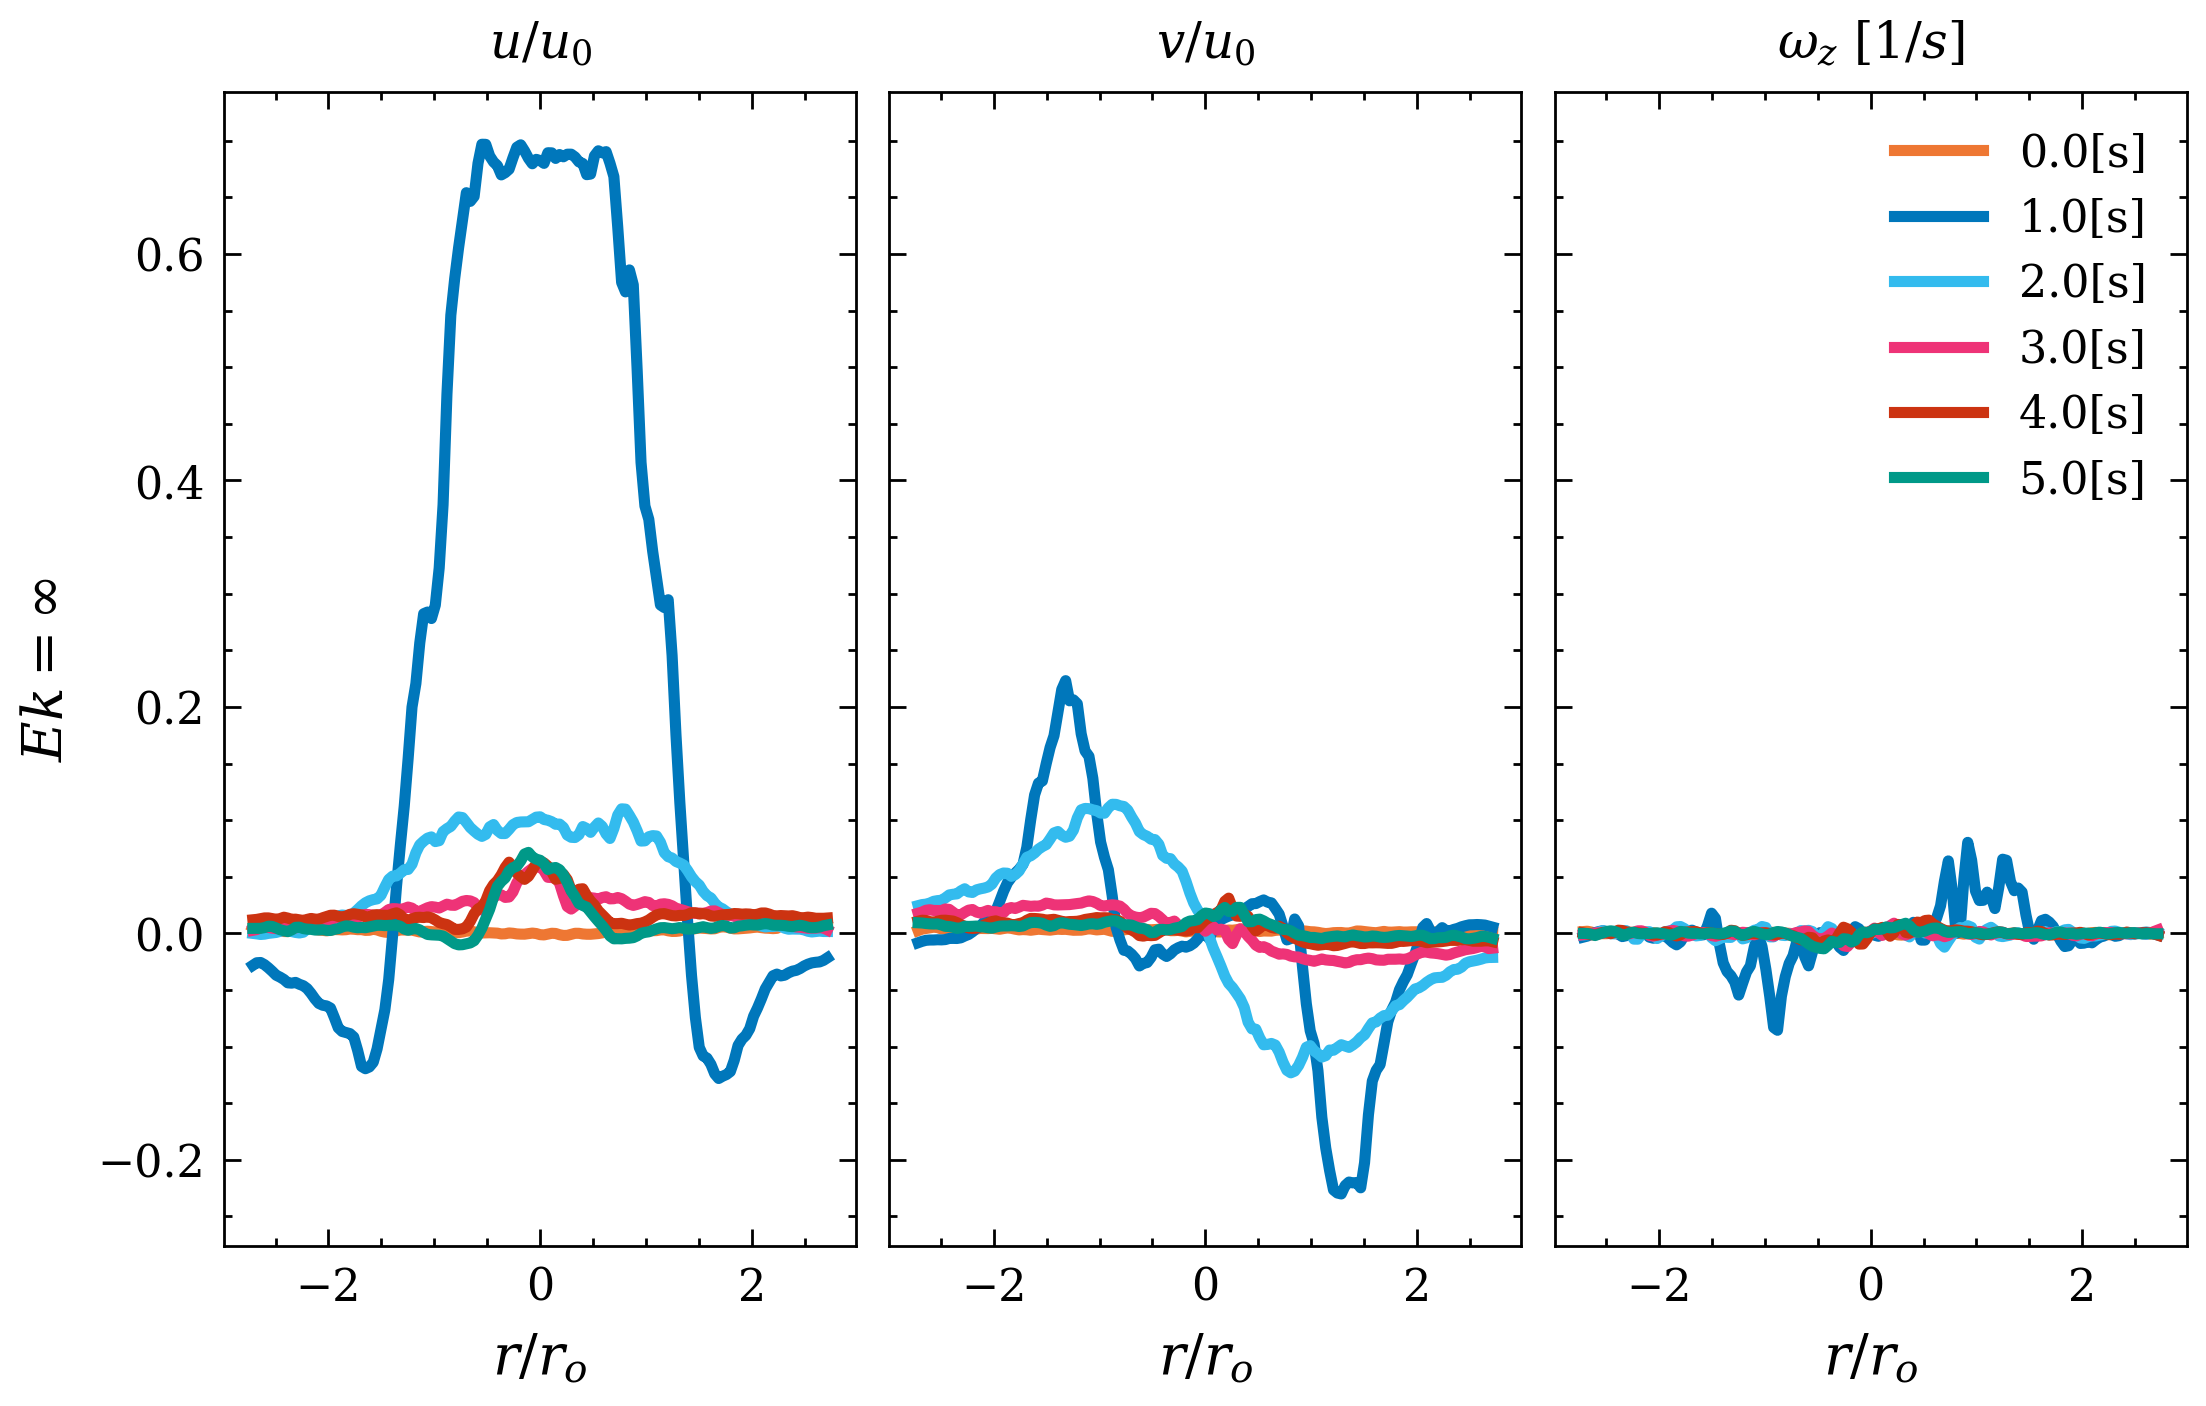

In [3]:
frame = 150
row = 43


# f1, ax = plt.subplots(1, 3, sharex=True, sharey=True)
# ax[0].plot(r_nd, u   [frame,:,row], label='u')
# ax[1].plot(r_nd, v   [frame,:,row], label='v')
# ax[2].plot(r_nd, vort[frame,:,row], label=r'$\omega_{z}$')
# plt.legend()
# plt.show()

f2, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5.5, 3.5), dpi = 400)
for frame in range(70, 610, 90):
    ax[0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0].plot(r_nd, u   [frame,:,row], label='')
    ax[0].set_xlabel(r"$r/r_{o}$")
    ax[0].set_ylabel(r"$Ek = \infty$")
    ax[1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[1].plot(r_nd, v   [frame,:,row], label='')
    ax[1].set_xlabel(r"$r/r_{o}$")
    ax[2].set_title(r'$\omega_{z} ~[1/s]$', fontsize=9)
    ax[2].plot(r_nd, vort[frame,:,row], label= str((frame-70)/90) + '[s]')
    ax[2].legend(fontsize=8)
    ax[2].set_xlabel(r"$r/r_{o}$")
plt.show()

# f3, ax = plt.subplots(1, 1, sharex=True, sharey=True, dpi = 400)
# ax.plot(r_nd, u[200,:,row], label='u')
# plt.show()
# plt.rcParams["figure.dpi"] = 400

# print(plt.rcParams["figure.dpi"])

Make a plot containing multiple rotation rates.

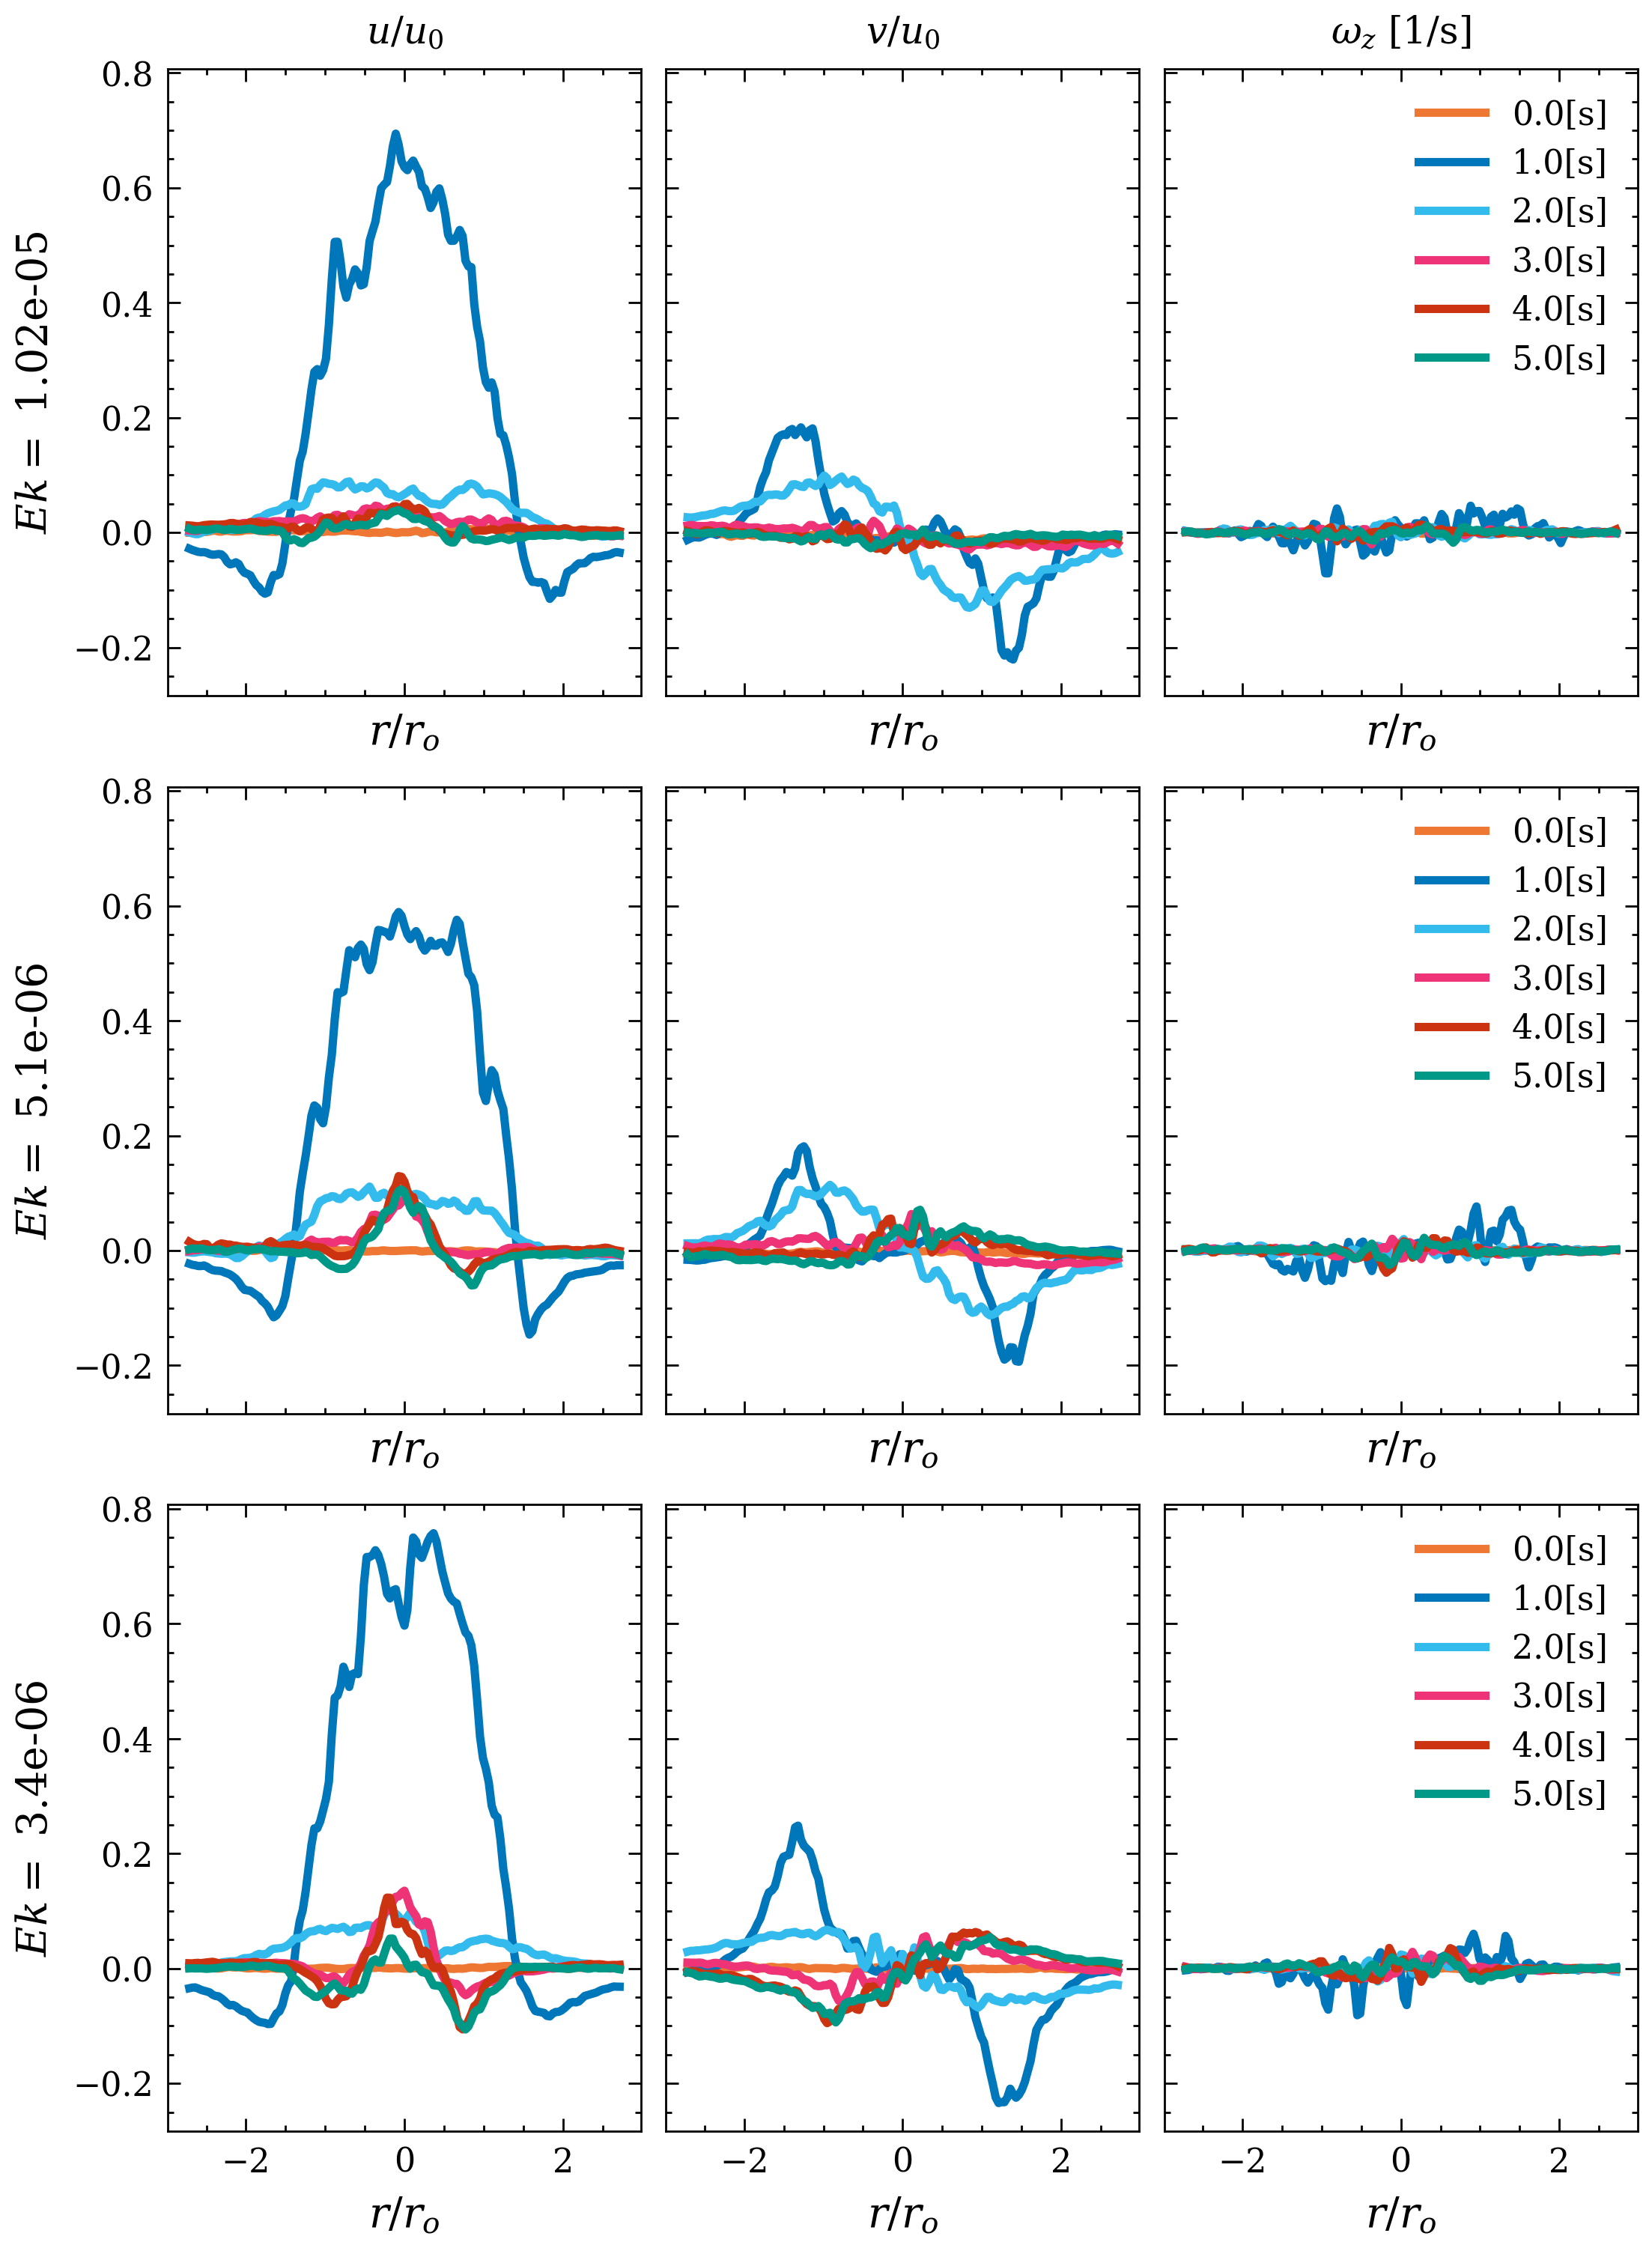

In [4]:
index = 0
rpms = [1, 2, 3]#, 6, 9, 12]
Eks = [0.0000102, 0.0000051, 0.0000034]#, 0.0000017, 0.0000011, 0.00000085]
# rpms = [6, 9, 12]
# Eks = [0.0000017, 0.0000011, 0.00000085]

f2, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
for i in range(3):
    ax[0, 0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0, 1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[0, 2].set_title(r'$\omega_{z}$ [1/s]', fontsize=9)

    vels = h5file['Narrow']['U100']['L100'][f'RPM{str(rpms[index])}']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
    u, v = u/0.1, v/0.1
    vort, vortGauss = oj.calculate_vorticity(u, v)

    for frame in range(70, 610, 90):
        ax[i, 0].plot(r_nd, u   [frame,:,row], label='')
        ax[i, 0].set_xlabel(r"$r/r_{o}$")
        ax[i, 0].set_ylabel(rf"$Ek =$ {Eks[index]}")
        ax[i, 1].plot(r_nd, v   [frame,:,row], label='')
        ax[i, 1].set_xlabel(r"$r/r_{o}$")
        ax[i, 2].plot(r_nd, vort[frame,:,row], label= str((frame-70)/90) + '[s]')
        ax[i, 2].legend(fontsize=8)
        ax[i, 2].set_xlabel(r"$r/r_{o}$")
    index += 1
plt.show()

Moving vortex ring profiles
Use the vortex ring tracking function to move the position of the section

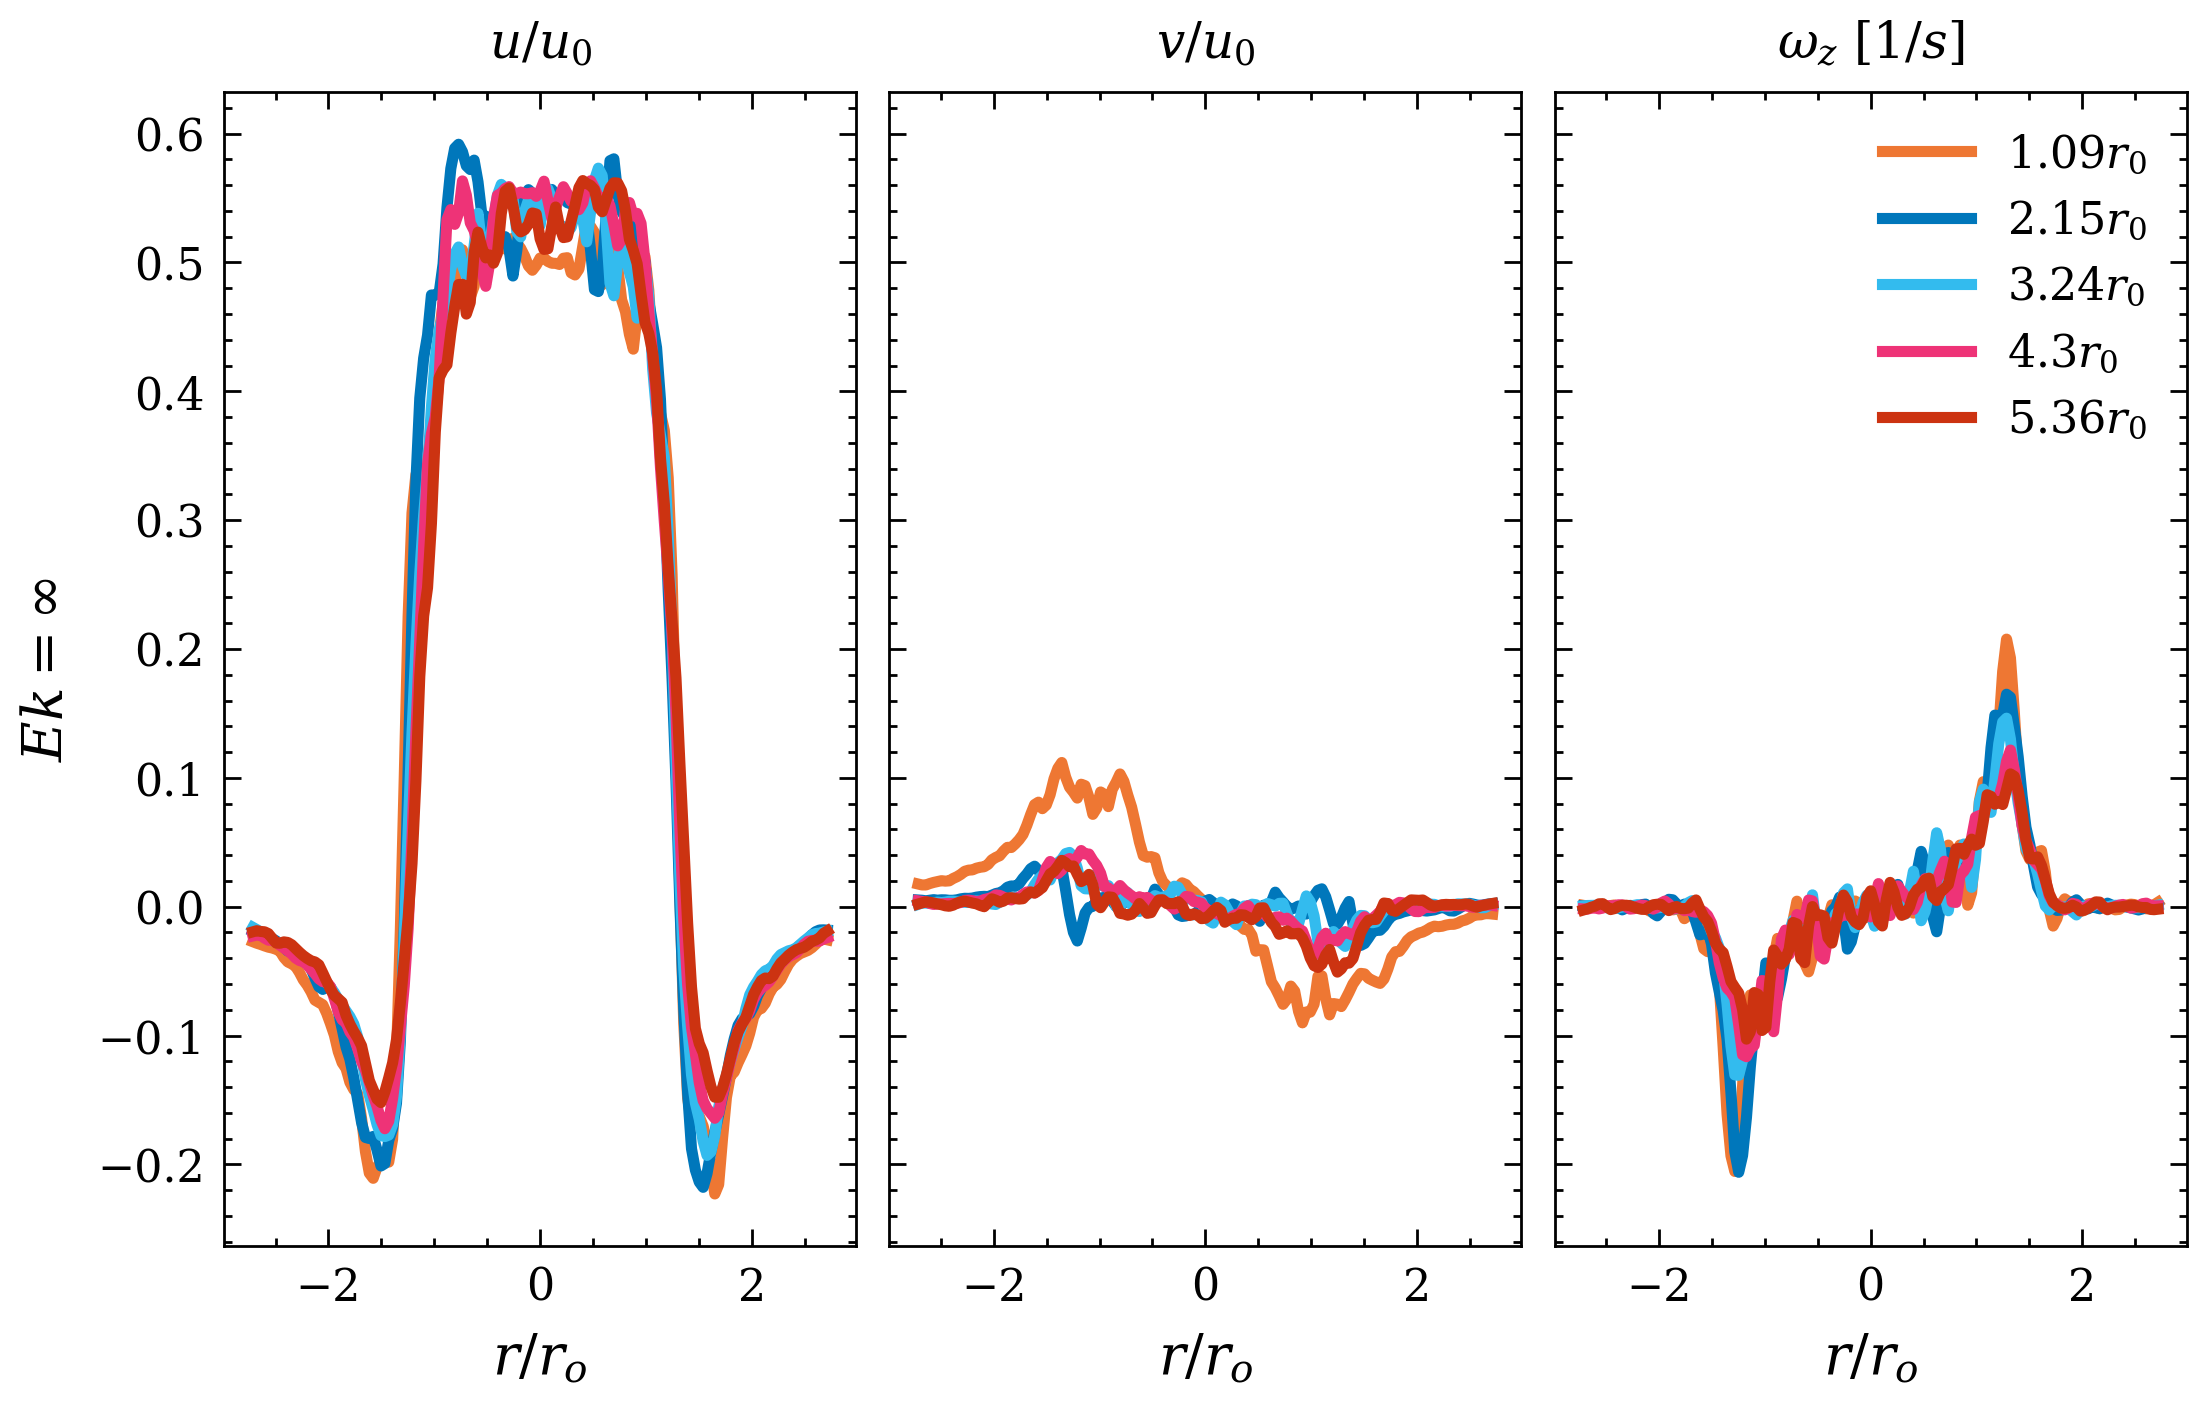

In [5]:
vels = h5file['Narrow']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1
vort, vortGauss = oj.calculate_vorticity(u, v)
VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u, v)
meanLoc = np.mean((VortLocMax[:,1], VortLocMin[:,1]), axis=0)
frame = 1000

# f2, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
# ax2.plot(VortLocMax[:,1], label='Max')
# ax2.plot(VortLocMin[:,1], label='Min')
# ax2.plot(meanLoc[:], label='Mean')
# plt.legend()

# print(meanLoc.shape)
# f3, ax = plt.subplots(1, 3, sharex=True, sharey=True)
# ax[0].plot(u   [frame,:,int(meanLoc[frame])], label='u')
# ax[1].plot(v   [frame,:,int(meanLoc[frame])], label='v')
# ax[2].plot(vort[frame,:,int(meanLoc[frame])], label=r'$\omega_{z}$')
# plt.show()

f4, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5.5, 3.5))
for i in range(200,650,90):
    ax[0].set_ylabel(r"$Ek = \infty$")
    ax[0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0].plot(r_nd, u   [i,:,int(meanLoc[i])], label='u')
    ax[0].set_xlabel(r"$r/r_{o}$")
    ax[1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[1].plot(r_nd, v   [i,:,int(meanLoc[i])], label='v')
    ax[1].set_xlabel(r"$r/r_{o}$")
    ax[2].set_title(r'$\omega_{z} ~[1/s]$', fontsize=9)
    ax[2].plot(r_nd, vort[i,:,int(meanLoc[i])], label= str(round(z_nd[int(meanLoc[i])], 2)) + r'$r_{0}$')
    ax[2].legend(prop={'size': 8})
    ax[2].set_xlabel(r"$r/r_{o}$")

plt.show()

# print(z_nd[int(meanLoc[200])])

3 $\times$ 3 plot of moving time series

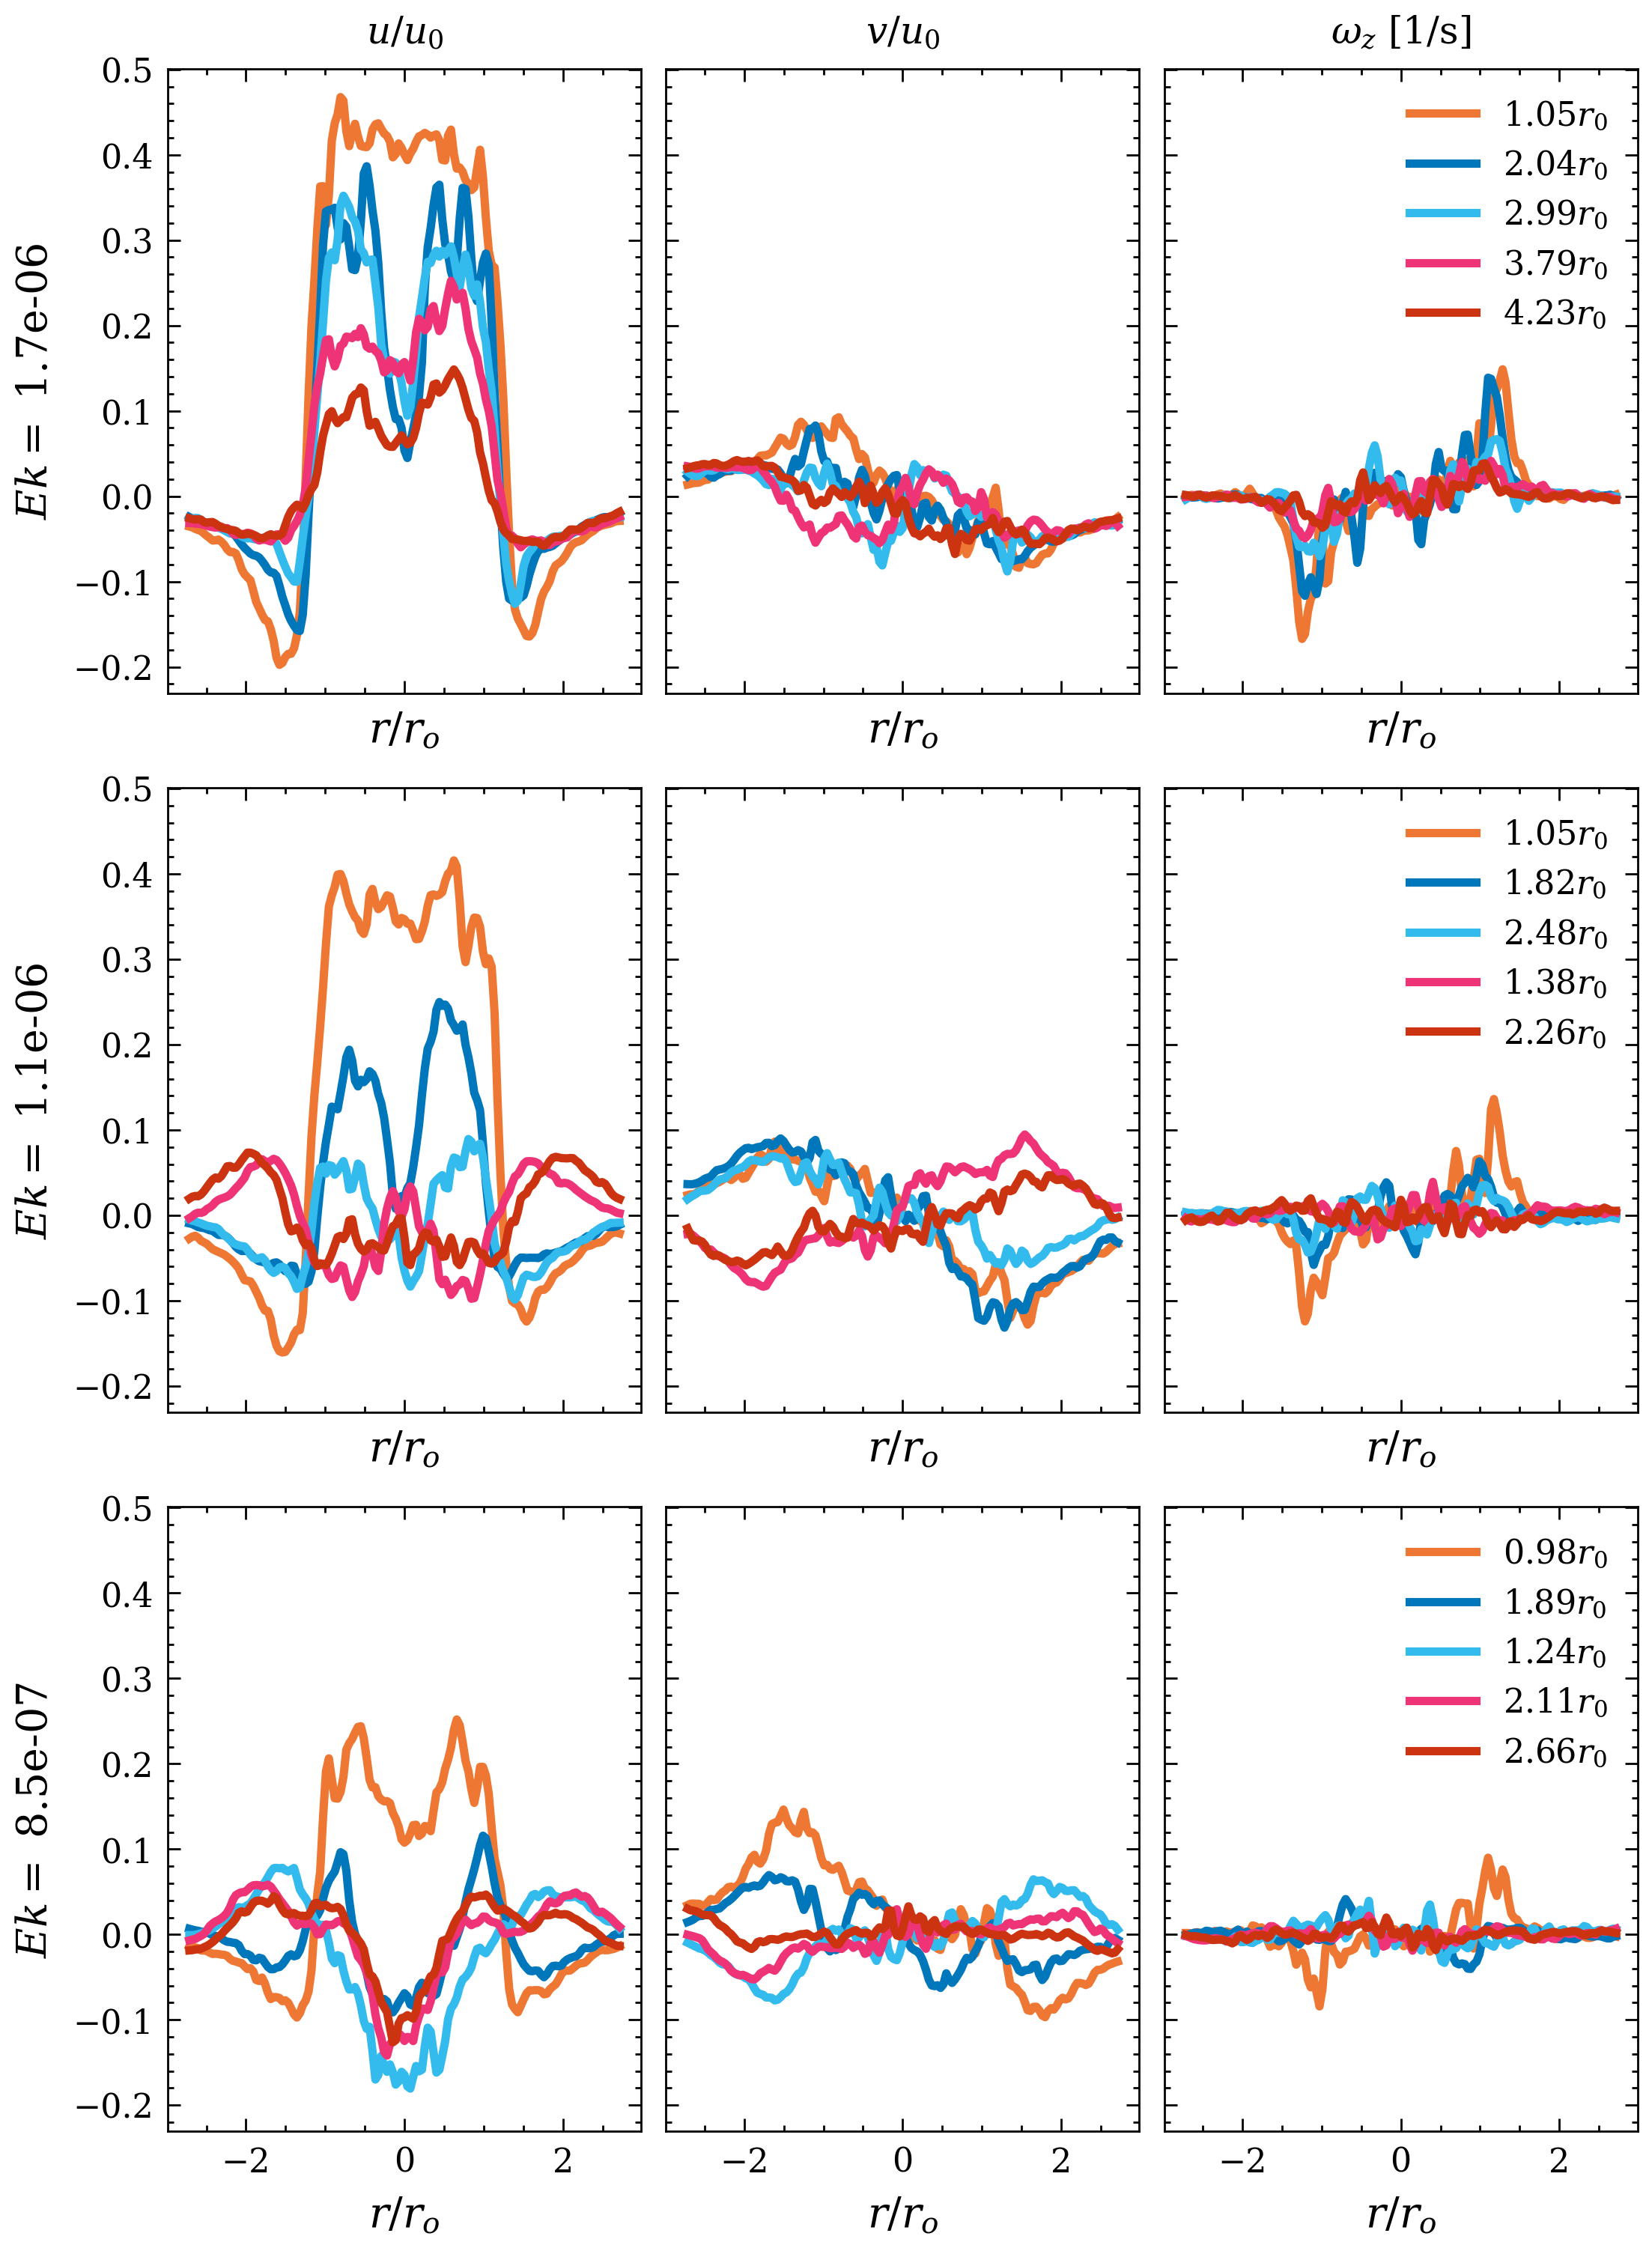

In [6]:
index = 0
rpms = [1, 2, 3]#, 6, 9, 12]
Eks = [0.0000102, 0.0000051, 0.0000034]#, 0.0000017, 0.0000011, 0.00000085]
rpms = [6, 9, 12]
Eks = [0.0000017, 0.0000011, 0.00000085]

f2, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
for i in range(3):
    ax[0, 0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0, 1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[0, 2].set_title(r'$\omega_{z}$ [1/s]', fontsize=9)

    vels = h5file['Narrow']['U100']['L100'][f'RPM{str(rpms[index])}']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
    u, v = u/0.1, v/0.1
    vort, vortGauss = oj.calculate_vorticity(u, v)
    VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u, v)
    meanLoc = np.mean((VortLocMax[:,1], VortLocMin[:,1]), axis=0)

    # for frame in range(70, 610, 90):
    #     ax[i, 0].plot(r_nd, u   [frame,:,row], label='')
    #     ax[i, 0].set_xlabel(r"$r/r_{o}$")
    #     ax[i, 0].set_ylabel(rf"$Ek =$ {Eks[index]}")
    #     ax[i, 1].plot(r_nd, v   [frame,:,row], label='')
    #     ax[i, 1].set_xlabel(r"$r/r_{o}$")
    #     ax[i, 2].plot(r_nd, vort[frame,:,row], label= str((frame-70)/90) + '[s]')
    #     ax[i, 2].legend(fontsize=8)
    #     ax[i, 2].set_xlabel(r"$r/r_{o}$")

    for frame in range(200,650,90):
        ax[i, 0].plot(r_nd, u   [frame,:,int(meanLoc[frame])], label='u')
        ax[i, 0].set_xlabel(r"$r/r_{o}$")
        ax[i, 0].set_ylabel(rf"$Ek =$ {Eks[index]}")
        ax[i, 1].plot(r_nd, v   [frame,:,int(meanLoc[frame])], label='v')
        ax[i, 1].set_xlabel(r"$r/r_{o}$")
        ax[i, 2].plot(r_nd, vort[frame,:,int(meanLoc[frame])], label= str(round(z_nd[int(meanLoc[frame])], 2)) + r'$r_{0}$')
        ax[i, 2].legend(prop={'size': 8})
        ax[i, 2].set_xlabel(r"$r/r_{o}$")
    index += 1
plt.show()